# Solar Geometry and Acquisition Validation: Landsat 8 and 9

Optical imagers acquire data only when their targets are adequately lit. `collect_observations` reports the solar geometry of each observation (the target's solar elevation and azimuth and its local solar time, with `omit_solar=False`), and an `Instrument` can require a minimum or maximum target solar elevation (`min_target_solar_elevation`, `max_target_solar_elevation`) for valid observations. This notebook compares both with the scenes acquired by the Operational Land Imager (OLI) of [Landsat 8 and 9](https://www.usgs.gov/landsat-missions) over one 16-day repeat cycle, from 17 September to 2 October 2026, and asks:

1. **Solar geometry.** Does TAT-C reproduce the time and the solar elevation and azimuth of each scene, by day and by night?
2. **Acquisition.** Which predicted passes does Landsat acquire, and does a minimum target solar elevation reproduce its acquisitions?

## Reference Data

The U.S. Geological Survey (USGS) [Landsat STAC catalog](https://landsatlook.usgs.gov/stac-server) (anonymous access) is searched for every Collection 2 Level-1 scene acquired during the analysis period. Each scene is a 185 km by 180 km frame of the Worldwide Reference System (WRS-2) with its footprint, its center time, and the solar elevation and azimuth at its center. Landsat acquires land and coastal areas by day and, on request, some areas at night (for example, thermal images of volcanoes and fires). The scene list (about 20 MB) is cached in a local `data/landsat` directory.

The satellites are modeled with two-line element sets (TLEs) from [CelesTrak](https://celestrak.org/) with epochs of 4 October 2026 and OLI with its 185 km swath from a 705 km altitude.

In [1]:
import concurrent.futures
import json
import time
from datetime import datetime, timedelta, timezone
from pathlib import Path

import cartopy.io.shapereader as shpreader
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from shapely import STRtree, contains_xy, prepare
from shapely.affinity import translate
from shapely.geometry import MultiPolygon
from shapely.ops import unary_union
from skyfield.api import wgs84

from tatc import utils
from tatc.analysis import collect_observations
from tatc.constants import timescale
from tatc.generation import generate_points_fibonacci_lattice
from tatc.schemas import GeneralPerturbationsOrbit, Instrument, Point, Satellite

DATA_DIR = Path("data") / "landsat"
DATA_DIR.mkdir(parents=True, exist_ok=True)
START = datetime(2026, 9, 17, tzinfo=timezone.utc)
END = datetime(2026, 10, 3, tzinfo=timezone.utc)
STAC = "https://landsatlook.usgs.gov/stac-server/search"
SCENES_FILE = DATA_DIR / f"landsat_c2l1_scenes_{START:%Y%m%d}_{END - timedelta(days=1):%Y%m%d}.geojson"
if not SCENES_FILE.exists():
    body = {
        "collections": ["landsat-c2l1"],
        "datetime": f"{START:%Y-%m-%dT%H:%M:%SZ}/{END - timedelta(seconds=1):%Y-%m-%dT%H:%M:%SZ}",
        "limit": 500,
        "fields": {
            "include": ["id", "geometry", "properties.datetime", "properties.platform", "properties.view:sun_elevation", "properties.view:sun_azimuth", "properties.view:off_nadir", "properties.landsat:wrs_path", "properties.landsat:wrs_row"],
            "exclude": ["links", "assets"],
        },
    }
    features = []
    while True:
        for attempt in range(6):
            try:
                response = requests.post(STAC, json=body, timeout=300)
                response.raise_for_status()
                page = response.json()
                break
            except (requests.RequestException, ValueError):
                if attempt == 5:
                    raise
                time.sleep(2**attempt)
        features += page["features"]
        following = [link for link in page.get("links", []) if link.get("rel") == "next"]
        if not following or not page["features"]:
            break
        body = following[0]["body"]
    SCENES_FILE.write_text(json.dumps({"type": "FeatureCollection", "features": features}))
scenes = gpd.read_file(SCENES_FILE).rename(columns={"view:sun_elevation": "sun_elevation", "view:sun_azimuth": "sun_azimuth", "view:off_nadir": "off_nadir"})
scenes["time"] = pd.to_datetime(scenes["datetime"], utc=True, format="ISO8601")
scenes["satellite"] = scenes.platform.str.replace("LANDSAT_", "Landsat ")


def scene_center(geometry):
    """Center of a scene footprint, unwrapping footprints split at the antimeridian."""
    if isinstance(geometry, MultiPolygon):
        geometry = unary_union([translate(part, xoff=360) if part.centroid.x < 0 else part for part in geometry.geoms])
    center = geometry.centroid
    return (center.x + 180) % 360 - 180, center.y


scenes["center_lon"], scenes["center_lat"] = zip(*scenes.geometry.map(scene_center))
TLES = {
    "Landsat 8": [
        "1 39084U 13008A   26277.62187981  .00000150  00000+0  43377-4 0  9995",
        "2 39084  98.2196 346.3945 0001312  94.4520 265.6828 14.57108036713830",
    ],
    "Landsat 9": [
        "1 49260U 21088A   26277.17558559  .00000158  00000+0  45237-4 0  9997",
        "2 49260  98.2176 345.9720 0001438  89.7555 270.3809 14.57106411266879",
    ],
}
SWATH = 185e3
oli = Instrument(name="OLI", field_of_regard=utils.swath_width_to_field_of_regard(705e3, SWATH))
satellites = {name: Satellite(name=name, orbit=GeneralPerturbationsOrbit.from_tle(tle), instruments=[oli]) for name, tle in TLES.items()}
BLUE, ORANGE, AQUA, GRAY, INK, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#8e5bd8"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})
pd.DataFrame(
    {
        "scenes": scenes.groupby("satellite").size(),
        "night scenes (sun below horizon)": scenes[scenes.sun_elevation < 0].groupby("satellite").size(),
        "off-nadir scenes": scenes[scenes.off_nadir > 0].groupby("satellite").size(),
        "first scene": scenes.groupby("satellite").time.min().dt.strftime("%Y-%m-%d %H:%M"),
        "last scene": scenes.groupby("satellite").time.max().dt.strftime("%Y-%m-%d %H:%M"),
    }
)

,scenes,night scenes (sun below horizon),off-nadir scenes,first scene,last scene
satellite,,,,,
Landsat 8,7977,365,3,2026-09-17 00:09,2026-09-27 07:44
Landsat 9,12231,552,5,2026-09-17 00:41,2026-10-02 23:41


Landsat 8 scenes end on 27 September 2026 (an outage or a gap in the catalog), so Landsat 8 is only assessed before then. A few night scenes were acquired with the satellite rolled about 7.6 deg off nadir, on request; as TAT-C models OLI viewing nadir, they are excluded.

## Test 1: Solar Geometry

For a random sample of 600 day scenes and 300 night scenes, `collect_observations` (with `omit_solar=False`) is evaluated at the scene center within 5 minutes of the scene center time. Its observation epoch, target solar elevation and azimuth, and local (apparent) solar time are compared with the scene's.

In [2]:
scenes = scenes[scenes.off_nadir.fillna(0) == 0].reset_index(drop=True)
sample = pd.concat([scenes[scenes.sun_elevation >= 0].sample(600, random_state=1), scenes[scenes.sun_elevation < 0].sample(300, random_state=1)])


def scene_geometry(scene):
    """TAT-C's observation of a scene center near the scene center time."""
    point = Point(id=0, latitude=scene.center_lat, longitude=scene.center_lon)
    window = timedelta(minutes=5)
    time = scene.time.floor("us")
    obs = collect_observations(point, satellites[scene.satellite], (time - window).to_pydatetime(), (time + window).to_pydatetime(), omit_solar=False)
    if obs.empty:
        return {"id": scene.id, "found": False}
    o = obs.iloc[0]
    return {
        "id": scene.id,
        "found": True,
        "night": scene.sun_elevation < 0,
        "epoch difference (s)": (o.epoch - scene.time).total_seconds(),
        "sun elevation": scene.sun_elevation,
        "TAT-C solar elevation": o.solar_alt,
        "solar elevation difference (deg)": o.solar_alt - scene.sun_elevation,
        "solar azimuth difference (deg)": (o.solar_az - scene.sun_azimuth + 180) % 360 - 180,
        "local solar time (h)": o.solar_time,
        "latitude": scene.center_lat,
    }


with concurrent.futures.ThreadPoolExecutor(8) as pool:
    geometry1 = pd.DataFrame(list(pool.map(scene_geometry, sample.itertuples())))
found = geometry1[geometry1.found]
table1 = {}
for label, subset in [("day scenes", found[~found.night.astype(bool)]), ("night scenes", found[found.night.astype(bool)])]:
    table1[label] = {"scenes": len(subset)}
    for column in ["epoch difference (s)", "solar elevation difference (deg)", "solar azimuth difference (deg)"]:
        table1[label][f"{column}, median"] = subset[column].median()
        table1[label][f"{column}, max |x|"] = subset[column].abs().max()
    table1[label]["local solar time, range (h)"] = f"{subset['local solar time (h)'].min():.2f} to {subset['local solar time (h)'].max():.2f}"
pd.DataFrame(table1).T.assign(**{"scenes found": f"{geometry1.found.sum()} of {len(geometry1)}"})

,scenes,"epoch difference (s), median","epoch difference (s), max |x|","solar elevation difference (deg), median","solar elevation difference (deg), max |x|","solar azimuth difference (deg), median","solar azimuth difference (deg), max |x|","local solar time, range (h)",scenes found
day scenes,600,-0.031266,0.596768,0.003337,0.02487,-0.001108,0.045688,7.48 to 16.30,900 of 900
night scenes,300,0.213529,0.717086,0.001675,0.025046,-0.002831,0.061111,0.92 to 23.08,900 of 900


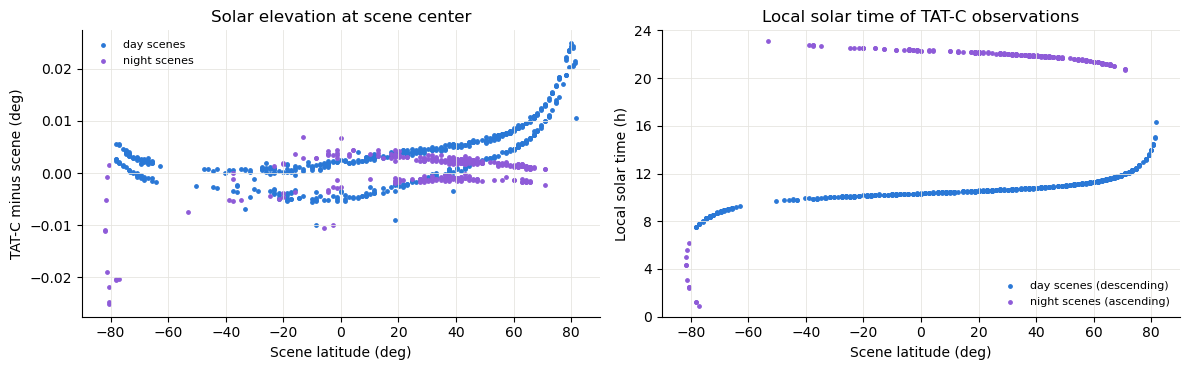

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
night = found.night.astype(bool)
axes[0].scatter(found.latitude[~night], found["solar elevation difference (deg)"][~night], s=6, color=BLUE, label="day scenes")
axes[0].scatter(found.latitude[night], found["solar elevation difference (deg)"][night], s=6, color=PURPLE, label="night scenes")
axes[0].set(xlabel="Scene latitude (deg)", ylabel="TAT-C minus scene (deg)", title="Solar elevation at scene center")
axes[0].legend(frameon=False, fontsize=8)
axes[1].scatter(found.latitude[~night], found["local solar time (h)"][~night], s=6, color=BLUE, label="day scenes (descending)")
axes[1].scatter(found.latitude[night], found["local solar time (h)"][night], s=6, color=PURPLE, label="night scenes (ascending)")
axes[1].set(xlabel="Scene latitude (deg)", ylabel="Local solar time (h)", title="Local solar time of TAT-C observations", ylim=(0, 24), yticks=range(0, 25, 4))
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

TAT-C observes every scene center within 0.7 s of the scene center time (median -0.03 s by day and +0.2 s by night), and its target solar elevation and azimuth agree with the scene's to within 0.025 deg and 0.06 deg. The small differences in elevation grow toward high northern latitudes, where the footprint's centroid, used here as the scene center, departs most from the scene's nominal center. By day, Landsat observes on descending passes at about 10:20 local apparent solar time near the equator (its 10:00 mean local time plus the equation of time, about 10 minutes in late September), from about 7:30 near 80 deg south to 16:00 near 80 deg north. At night, it observes on ascending passes at about 22:00, with local times running through midnight near the South Pole.

## Test 2: Acquisition

The points of interest are those of a Fibonacci lattice with a typical spacing of 500 km on land (Natural Earth 1:110 million land polygons, including Antarctica) within the latitudes Landsat images (81.8 deg south to 81.8 deg north). For each point, `collect_observations` predicts every pass of each satellite over the analysis period (Landsat 8 until 26 September), by day and by night. A predicted pass is acquired if a scene of that satellite whose footprint contains the point has a center time within 3 minutes of the predicted epoch (scenes overlap, so a pass may have several).

In [4]:
land = unary_union(list(shpreader.Reader(shpreader.natural_earth(resolution="110m", category="physical", name="land")).geometries()))
prepare(land)
lattice = generate_points_fibonacci_lattice(500e3)
points = lattice[contains_xy(land, lattice.geometry.x, lattice.geometry.y) & (lattice.geometry.y.abs() < 81.8)].reset_index(drop=True)
points["point_id"] = points.index
END_BY_SATELLITE = {"Landsat 8": datetime(2026, 9, 27, tzinfo=timezone.utc), "Landsat 9": END}


def predict(point, instrument=oli):
    """Predicted passes of each satellite over a point."""
    target = Point(id=point.point_id, latitude=point.geometry.y, longitude=point.geometry.x)
    frames = []
    for name, satellite in satellites.items():
        satellite = satellite.model_copy(update={"instruments": [instrument]})
        frames.append(collect_observations(target, satellite, START, END_BY_SATELLITE[name], omit_solar=False))
    return pd.concat(frames)


with concurrent.futures.ThreadPoolExecutor(8) as pool:
    predicted = pd.concat(list(pool.map(predict, points.itertuples()))).reset_index(drop=True)

# acquired passes: scenes containing each point, one per point, satellite, and pass
tree = STRtree(scenes.geometry.values)
rows = []
for point in points.itertuples():
    for k in tree.query(point.geometry, predicate="intersects"):
        scene = scenes.iloc[k]
        if scene.time < END_BY_SATELLITE[scene.satellite]:
            rows.append({"point_id": point.point_id, "satellite": scene.satellite, "time": scene.time, "sun_elevation": scene.sun_elevation})
acquired = pd.DataFrame(rows).sort_values("time")
new_pass = acquired.groupby(["point_id", "satellite"]).time.diff() > pd.Timedelta(minutes=5)
acquired["pass"] = new_pass.groupby([acquired.point_id, acquired.satellite]).cumsum()
acquired = acquired.groupby(["point_id", "satellite", "pass"]).agg(time=("time", "mean"), sun_elevation=("sun_elevation", "mean")).reset_index()


def match(predicted, acquired):
    """Flag predicted passes that were acquired, and acquired passes that were predicted."""
    tolerance = pd.Timedelta(minutes=3)
    pairs = pd.merge_asof(predicted.sort_values("epoch"), acquired[["point_id", "satellite", "time"]].sort_values("time"), left_on="epoch", right_on="time", by=["point_id", "satellite"], direction="nearest", tolerance=tolerance)
    pairs["acquired"] = pairs.time.notna()
    back = pd.merge_asof(acquired.sort_values("time"), predicted[["point_id", "satellite", "epoch"]].sort_values("epoch"), left_on="time", right_on="epoch", by=["point_id", "satellite"], direction="nearest", tolerance=tolerance)
    back["predicted"] = back.epoch.notna()
    return pairs, back


pairs, back = match(predicted, acquired)
pairs = pairs.merge(points[["point_id"]].assign(latitude=points.geometry.y), on="point_id")
pairs["region"] = np.where(pairs.latitude < -60, "Antarctica (south of 60 deg S)", np.where(pairs.latitude > 60, "north of 60 deg N", "60 deg S to 60 deg N"))
BINS = [-90, -10, 0, 2, 4, 5, 6, 8, 10, 15, 20, 30, 90]
pairs["solar elevation (deg)"] = pd.cut(pairs.solar_alt, BINS)
pd.DataFrame(
    {
        "points": len(points),
        "predicted passes": pairs.groupby("satellite").size(),
        "predicted passes by day": pairs[pairs.solar_alt >= 0].groupby("satellite").size(),
        "acquired passes": back.groupby("satellite").size(),
        "acquired passes predicted (%)": 100 * back.groupby("satellite").predicted.mean(),
    }
).round(1)

,points,predicted passes,predicted passes by day,acquired passes,acquired passes predicted (%)
satellite,,,,,
Landsat 8,737,1811,878,785,99.4
Landsat 9,737,2907,1419,1265,99.1


In [5]:
table2 = pairs.groupby(["solar elevation (deg)", "satellite"], observed=True).acquired.agg(["mean", "size"]).unstack()
table2.columns = [f"{satellite}: {'acquired (%)' if stat == 'mean' else 'predicted passes'}" for stat, satellite in table2.columns]
for column in [c for c in table2.columns if "acquired" in c]:
    table2[column] *= 100
table2.round(1)

,Landsat 8: acquired (%),Landsat 9: acquired (%),Landsat 8: predicted passes,Landsat 9: predicted passes
solar elevation (deg),,,,
"(-90, -10]",3.8,4.5,783,1249
"(-10, 0]",2.0,1.3,150,239
"(0, 2]",3.2,0.0,31,41
"(2, 4]",0.0,0.0,30,48
"(4, 5]",6.7,25.0,15,24
"(5, 6]",28.6,50.0,14,24
"(6, 8]",63.6,55.4,33,65
"(8, 10]",51.4,57.4,35,54
"(10, 15]",74.1,68.3,58,104


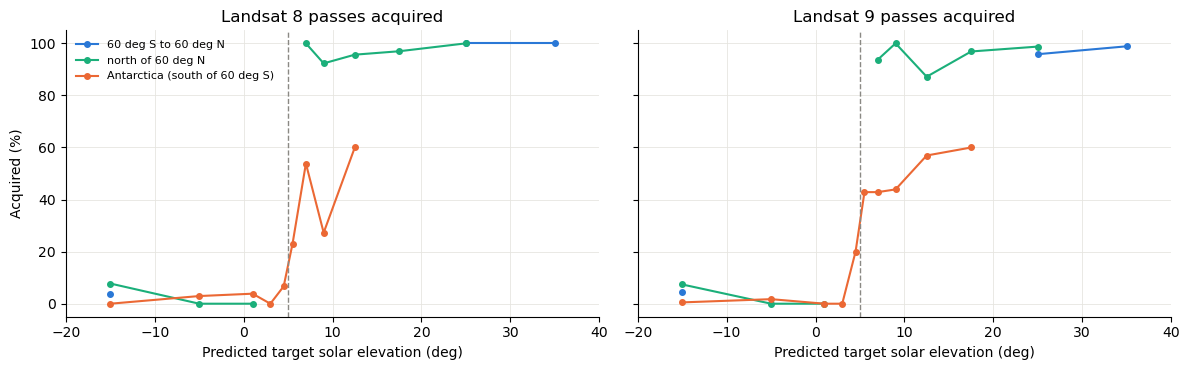

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
centers = [(max(a, -20) + min(b, 40)) / 2 for a, b in zip(BINS[:-1], BINS[1:])]
for ax, satellite in zip(axes, satellites):
    for region, color in zip(["60 deg S to 60 deg N", "north of 60 deg N", "Antarctica (south of 60 deg S)"], [BLUE, AQUA, ORANGE]):
        subset = pairs[(pairs.satellite == satellite) & (pairs.region == region)]
        stats = subset.groupby("solar elevation (deg)", observed=False).acquired.agg(["mean", "size"])
        # omit bins with fewer than 5 passes (breaking the line)
        ax.plot(centers, 100 * stats["mean"].where(stats["size"] >= 5), "o-", color=color, ms=4, label=region)
    ax.axvline(5, color=GRAY, ls="--", lw=1)
    ax.set(xlabel="Predicted target solar elevation (deg)", title=f"{satellite} passes acquired", xlim=(-20, 40))
axes[0].set_ylabel("Acquired (%)")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

Landsat acquires nearly every predicted pass with the Sun more than 20 deg above the target's horizon (98 to 100%), and almost none with the Sun below 4 deg (none between 2 and 4 deg). In between, acquisition depends on the region: north of 60 deg N, 87 to 100% of passes with the Sun above 5 deg are acquired, whereas over Antarctica, where the Sun is rising after the polar winter, only about half of the passes with the Sun between 5 and 20 deg are. At night, 1 to 5% of passes are acquired, on request. Landsat 8 (before its scenes end) and Landsat 9 follow the same plan.

The acquired passes that TAT-C does not predict are located from the satellite's ground track at the time it passes closest to each point.

In [7]:
wide = Instrument(name="wide", field_of_regard=utils.swath_width_to_field_of_regard(705e3, 300e3))


def ground_track_distance(row):
    """Distance (km) of a point from the ground track at the satellite's closest approach."""
    point = points.loc[row.point_id].geometry
    satellite = satellites[row.satellite].model_copy(update={"instruments": [wide]})
    window = timedelta(minutes=5)
    time = row.time.floor("us")
    obs = collect_observations(Point(id=0, latitude=point.y, longitude=point.x), satellite, (time - window).to_pydatetime(), (time + window).to_pydatetime())
    if obs.empty:
        return np.nan
    epoch = obs.epoch.iloc[0].floor("us").to_pydatetime()
    subpoint = wgs84.subpoint_of(satellites[row.satellite].orbit.to_gp_orbit().elements[0].to_skyfield().at(timescale.from_datetime(epoch)))
    return utils.geometry.geodesic_distance(point.x, point.y, subpoint.longitude.degrees, subpoint.latitude.degrees) / 1e3


unpredicted = back[~back.predicted].copy()
unpredicted["distance from ground track (km)"] = [ground_track_distance(row) for row in unpredicted.itertuples()]
unpredicted["time"] = unpredicted.time.dt.strftime("%Y-%m-%d %H:%M:%S")
unpredicted[["point_id", "satellite", "time", "sun_elevation", "distance from ground track (km)"]].round(1)

,point_id,satellite,time,sun_elevation,distance from ground track (km)
69,588,Landsat 9,2026-09-17 09:01:07,38.9,93.4
162,637,Landsat 8,2026-09-18 02:17:21,32.4,93.6
231,436,Landsat 9,2026-09-18 08:10:40,53.4,93.1
380,317,Landsat 8,2026-09-19 08:08:49,62.5,92.7
479,691,Landsat 9,2026-09-20 01:13:26,24.7,93.7
623,75,Landsat 8,2026-09-20 23:55:37,46.6,94.0
627,676,Landsat 9,2026-09-21 00:18:26,26.3,94.2
966,404,Landsat 8,2026-09-23 03:49:57,-49.1,93.1
1034,54,Landsat 8,2026-09-23 14:36:50,36.8,95.2
1172,640,Landsat 9,2026-09-24 09:05:23,30.1,93.6


Nearly all acquired passes (99.1 to 99.4%) are predicted. The 16 that are not lie 92.7 to 97.4 km from the ground track, just beyond the 92.5 km half-width of the nominal 185 km swath: the scenes contain image data up to about 5 km beyond the nominal swath on each side, so OLI's swath is about 190 km wide.

Finally, OLI is modeled with a minimum target solar elevation of 5 deg (`min_target_solar_elevation=5`), so that only passes over targets with the Sun at least 5 deg above the horizon are valid observations, and the predictions are compared with the acquisitions again.

In [8]:
oli_5 = oli.model_copy(update={"min_target_solar_elevation": 5})
with concurrent.futures.ThreadPoolExecutor(8) as pool:
    predicted_5 = pd.concat(list(pool.map(lambda point: predict(point, oli_5), points.itertuples()))).reset_index(drop=True)
pairs_5, back_5 = match(predicted_5, acquired)
rows3 = {}
for label, p, b in [("no solar requirement", pairs, back), ("min_target_solar_elevation = 5", pairs_5, back_5)]:
    for satellite in satellites:
        ps, bs = p[p.satellite == satellite], b[b.satellite == satellite]
        rows3[(label, satellite)] = {
            "predicted passes": len(ps),
            "acquired passes": len(bs),
            "predicted passes acquired (%)": 100 * ps.acquired.mean(),
            "acquired passes predicted (%)": 100 * bs.predicted.mean(),
            "predicted, not acquired": int((~ps.acquired).sum()),
            "predicted, not acquired, south of 60 deg S (%)": 100 * np.mean(ps[~ps.acquired].point_id.map(points.geometry.y) < -60),
            "acquired, not predicted: Sun below horizon": int((~bs.predicted & (bs.sun_elevation < 0)).sum()),
            "acquired, not predicted: Sun 0 to 5 deg": int((~bs.predicted & (bs.sun_elevation >= 0) & (bs.sun_elevation < 5)).sum()),
            "acquired, not predicted: Sun above 5 deg": int((~bs.predicted & (bs.sun_elevation >= 5)).sum()),
        }
pd.DataFrame(rows3).T.round(1)

predicted passes  acquired passes  \
no solar requirement           Landsat 8            1811.0            785.0   
                               Landsat 9            2907.0           1265.0   
min_target_solar_elevation = 5 Landsat 8             802.0            785.0   
                               Landsat 9            1306.0           1265.0   

                                          predicted passes acquired (%)  \
no solar requirement           Landsat 8                           43.1   
                               Landsat 9                           43.1   
min_target_solar_elevation = 5 Landsat 8                           92.9   
                               Landsat 9                           91.0   

                                          acquired passes predicted (%)  \
no solar requirement           Landsat 8                           99.4   
                               Landsat 9                           99.1   
min_target_solar_elevation = 5 Landsat 8                           94.9   
                               Landsat 9                           94.0   

                                          predicted, not acquired  \
no solar requirement           Landsat 8                   1031.0   
                               Landsat 9                   1653.0   
min_target_solar_elevation = 5 Landsat 8                     57.0   
                               Landsat 9                    117.0   

                                          predicted, not acquired, south of 60 deg S (%)  \
no solar requirement           Landsat 8                                            35.1   
                               Landsat 9                                            33.8   
min_target_solar_elevation = 5 Landsat 8                                            94.7   
                               Landsat 9                                            82.9   

                                          acquired, not predicted: Sun below horizon  \
no solar requirement           Landsat 8                                         1.0   
                               Landsat 9                                         0.0   
min_target_solar_elevation = 5 Landsat 8                                        34.0   
                               Landsat 9                                        59.0   

                                          acquired, not predicted: Sun 0 to 5 deg  \
no solar requirement           Landsat 8                                      0.0   
                               Landsat 9                                      0.0   
min_target_solar_elevation = 5 Landsat 8                                      1.0   
                               Landsat 9                                      2.0   

                                          acquired, not predicted: Sun above 5 deg  
no solar requirement           Landsat 8                                       4.0  
                               Landsat 9                                      11.0  
min_target_solar_elevation = 5 Landsat 8                                       5.0  
                               Landsat 9                                      15.0

With a minimum target solar elevation of 5 deg, TAT-C predicts 802 and 1,306 passes (instead of 1,811 and 2,907), of which 91 to 93% are acquired (instead of 43%), while it still predicts 94 to 95% of the acquired passes. Of the predicted passes that are not acquired, 83 to 95% are over Antarctica, whose partial acquisition at low Sun no single threshold reproduces. Only 3 acquired daytime passes with the Sun between 0 and 5 deg are no longer predicted. The night acquisitions that are no longer predicted (93) are made on request; they could be modeled with a second instrument with a maximum target solar elevation (for example, `max_target_solar_elevation=0`) over the requested areas.

## Summary

| Test | Result |
| --- | --- |
| 1. Solar geometry (`omit_solar=False`) | target solar elevation and azimuth within 0.025 and 0.06 deg of 900 day and night scenes; observation epochs within 0.7 s of scene center times |
| 2. Acquisition (`min_target_solar_elevation`) | Landsat acquires 98 to 100% of passes with the Sun above 20 deg and none with the Sun below 4 deg; with a 5 deg minimum, 91 to 93% of predicted passes are acquired (43% without) and 94 to 95% of acquired passes are predicted |

**Solar geometry.** TAT-C's solar elevation, azimuth, and local solar time match those of Landsat's scenes by day and by night, so they can be used to model illumination requirements.

**Acquisition.** Landsat's acquisitions follow a minimum solar elevation of about 5 deg, which `min_target_solar_elevation` models: it removes the passes Landsat does not acquire (at night and with a low Sun) while keeping nearly all those it does. The remaining differences are an acquisition plan that is partial over Antarctica at low Sun, night acquisitions on request, and a swath about 5 km wider than the nominal 185 km on each side, which a 190 km swath would capture. As in the [Sentinel-2 revisit](ValidateRevisitSentinel2.ipynb) notebook, a minimum solar elevation of about 5 deg reproduces the acquisitions of a sun-synchronous land imager.